In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models.efficientnet import EfficientNet_B1_Weights
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
# Data transforms (EfficientNet B1 uses 240x240 input)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(240),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(240),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (update path)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform (no aug)
val_dataset.dataset.transform = val_transform

# Loaders (batch 32; fits 6GB VRAM, ~3-4GB usage)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Classes
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train: 2088, Val: 523


In [10]:
# Load EfficientNet B1
model = models.efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)

# Freeze except classifier
for param in model.parameters():
    param.requires_grad = False

# Modify classifier
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 5)

# To GPU
model = model.to(device)

# Summary (optional)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Classifier only first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/100 - Train Loss: 0.2175, Acc: 0.9310 | Val Loss: 0.3391, Acc: 0.8776
Epoch 2/100 - Train Loss: 0.2260, Acc: 0.9349 | Val Loss: 0.3404, Acc: 0.8853
Epoch 3/100 - Train Loss: 0.2158, Acc: 0.9296 | Val Loss: 0.3406, Acc: 0.8757
Epoch 4/100 - Train Loss: 0.2241, Acc: 0.9310 | Val Loss: 0.3427, Acc: 0.8834
Epoch 5/100 - Train Loss: 0.2129, Acc: 0.9358 | Val Loss: 0.3422, Acc: 0.8853
Epoch 6/100 - Train Loss: 0.2101, Acc: 0.9320 | Val Loss: 0.3477, Acc: 0.8757
Epoch 7/100 - Train Loss: 0.2134, Acc: 0.9339 | Val Loss: 0.3396, Acc: 0.8776
Epoch 8/100 - Train Loss: 0.2278, Acc: 0.9277 | Val Loss: 0.3438, Acc: 0.8815
Epoch 9/100 - Train Loss: 0.2228, Acc: 0.9301 | Val Loss: 0.3401, Acc: 0.8795
Epoch 10/100 - Train Loss: 0.2174, Acc: 0.9363 | Val Loss: 0.3454, Acc: 0.8795
Epoch 11/100 - Train Loss: 0.2223, Acc: 0.9306 | Val Loss: 0.3313, Acc: 0.8834
Epoch 12/100 - Train Loss: 0.2275, Acc: 0.9239 | Val Loss: 0.3406, Acc: 0.8776
Epoch 13/100 - Train Loss: 0.2167, Acc: 0.9334 | Val Loss: 0.

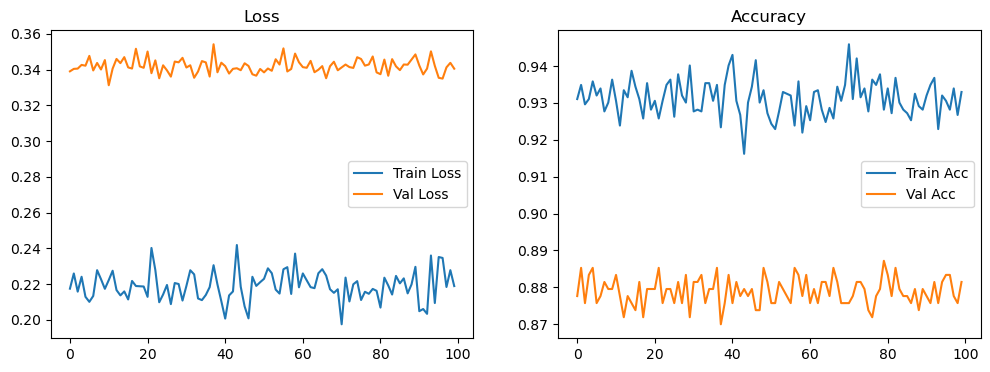

In [18]:
num_epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [20]:
# Eval
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
EfficientNetB1 = os.path.join(model_path, 'EfficientNetB1_1')
os.makedirs(EfficientNetB1, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(EfficientNetB1,'efficientnet_b1_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.77      0.79      0.78       107
      Cowpox       0.99      0.95      0.97        87
     Measles       0.94      0.91      0.93        92
   MonkeyPox       0.86      0.81      0.84       123
      Normal       0.88      0.96      0.92       114

    accuracy                           0.88       523
   macro avg       0.89      0.89      0.89       523
weighted avg       0.88      0.88      0.88       523

Accuracy: 0.8815
